<a href="https://colab.research.google.com/github/anand57577-lab/AI_RESUME_ANALYZER/blob/main/Resume_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#load the dataset
import pandas as pd
data = pd.read_csv('Resume Screening.csv')
df = pd.DataFrame(data)
df.shape


(962, 2)

In [ ]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [ ]:
try:
    data1 = pd.read_csv('Resume.csv', engine='python')
    df1 = pd.DataFrame(data1)
    print(f"Successfully loaded Resume.csv. Shape: {df1.shape}")
except (pd.errors.ParserError, FileNotFoundError) as e:
    print(f"Warning: Could not read 'Resume.csv' due to: {e}")
    print("Initializing df1 as an empty DataFrame with columns 'ID', 'Resume_html', 'Resume_str', 'Category' to allow subsequent cells to run.")
    # Initialize df1 with expected columns to prevent errors in later cells
    df1 = pd.DataFrame(columns=['ID', 'Resume_html', 'Resume_str', 'Category'])
    print(f"df1 initialized as empty. Shape: {df1.shape}")

Successfully loaded Resume.csv. Shape: (2484, 4)


In [ ]:
df1.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
df1 = df1.drop('ID', axis=1)
df1 = df1.drop('Resume_html', axis=1)

In [ ]:
df1.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [ ]:
df1['Resume'] = df1['Resume_str']
df1.drop('Resume_str', axis = 1 ,inplace = True)

In [ ]:
df1.head()

,Category,Resume
0,HR,HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1,HR,"HR SPECIALIST, US HR OPERATIONS ..."
2,HR,HR DIRECTOR Summary Over 2...
3,HR,HR SPECIALIST Summary Dedica...
4,HR,HR MANAGER Skill Highlights ...


In [ ]:
df = pd.concat([df,df1],axis=0, ignore_index=True)

In [ ]:
df.shape

(3446, 2)

In [ ]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [ ]:
df.Category.unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing',
       'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

In [ ]:
!pip install scikit-learn

<Axes: xlabel='Category'>

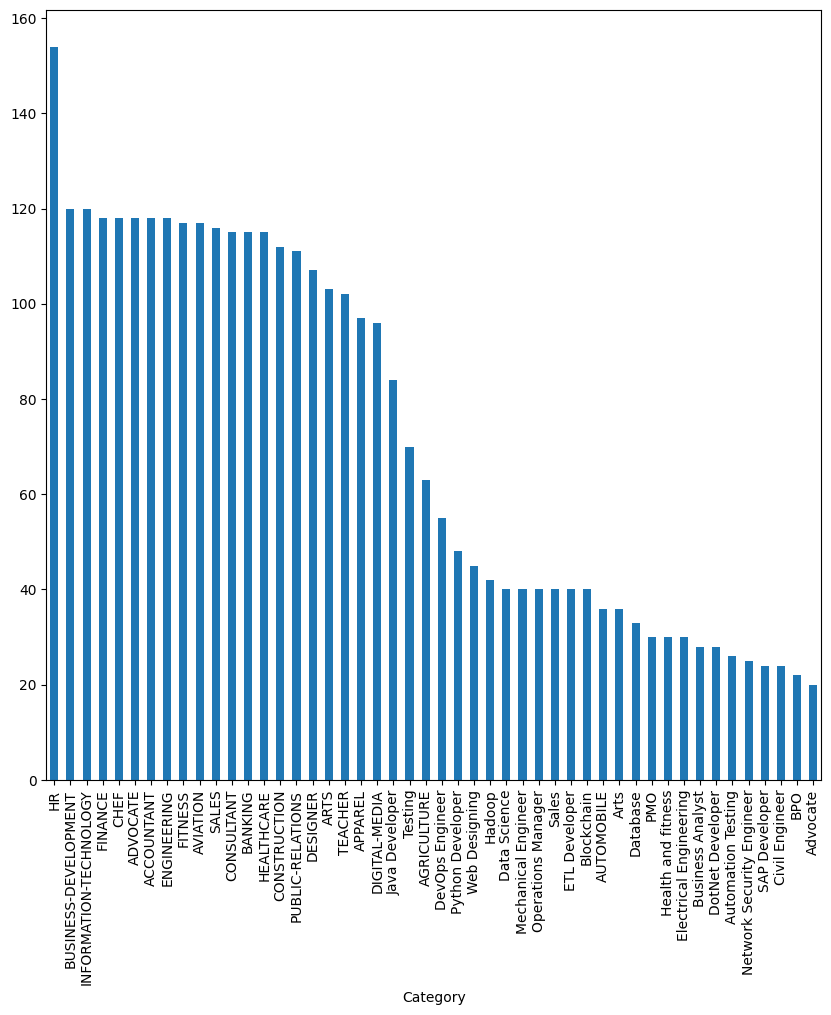

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,10))
df.Category.value_counts().plot(kind = 'bar')

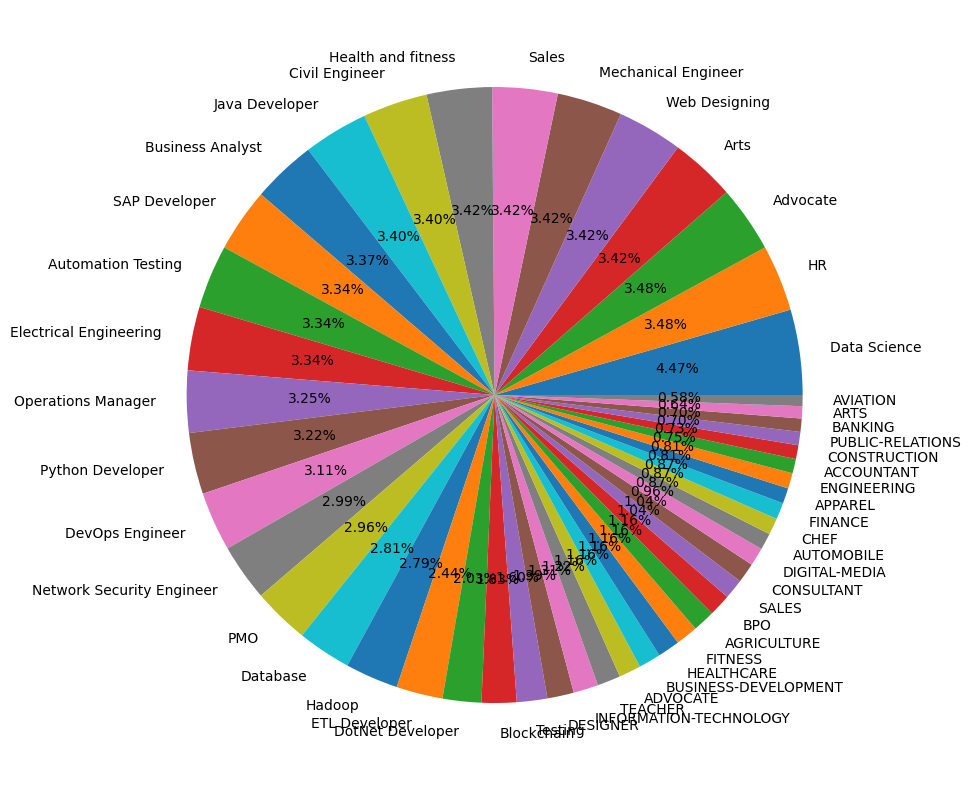

In [ ]:
value = df.Category.value_counts()
label = df.Category.unique()
plt.figure(figsize = (10,10))
plt.pie(value, labels = label, autopct = '%1.2f%%')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])
df.head()

,Category,Resume
0,21,Skills * Programming Languages: Python (pandas...
1,21,Education Details \r\nMay 2013 to May 2017 B.E...
2,21,"Areas of Interest Deep Learning, Control Syste..."
3,21,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,21,"Education Details \r\n MCA YMCAUST, Faridab..."


<Axes: xlabel='Category'>

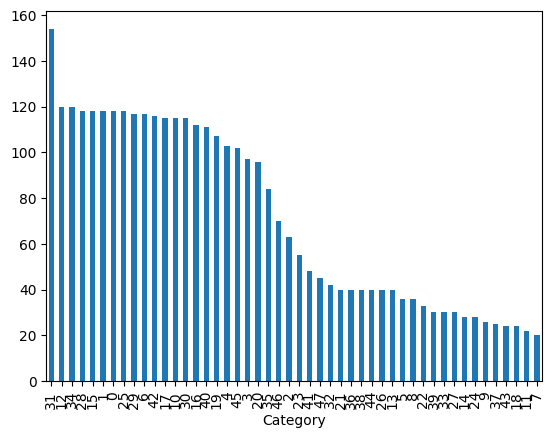

In [ ]:
import matplotlib.pyplot as plt
df.Category.value_counts().plot(kind = 'bar')

In [ ]:
df.shape

(3446, 2)

In [ ]:
df['Resume'].value_counts()

Resume
Technical Skills Web Technologies: Angular JS, HTML5, CSS3, SASS, Bootstrap, Jquery, Javascript. Software: Brackets, Visual Studio, Photoshop, Visual Studio Code Education Details \r\nJanuary 2015 B.E CSE Nagpur, Maharashtra G.H.Raisoni College of Engineering\r\nOctober 2009  Photography Competition Click Nagpur, Maharashtra Maharashtra State Board\r\n    College Magazine OCEAN\r\nWeb Designer \r\n\r\nWeb Designer - Trust Systems and Software\r\nSkill Details \r\nPHOTOSHOP- Exprience - 28 months\r\nBOOTSTRAP- Exprience - 6 months\r\nHTML5- Exprience - 6 months\r\nJAVASCRIPT- Exprience - 6 months\r\nCSS3- Exprience - Less than 1 year months\r\nAngular 4- Exprience - Less than 1 year monthsCompany Details \r\ncompany - Trust Systems and Software\r\ndescription - Projects worked on:\r\n1. TrustBank-CBS\r\nProject Description: TrustBank-CBS is a core banking solution by Trust Systems.\r\nRoles and Responsibility:\r\nâ Renovated complete UI to make it more modern, user-friendly, maintainable and optimised for bank use.\r\nâ Shared the UI structure and guidelines to be incorporated, with development team of around 50\r\nmembers.\r\nâ Achieved the target of project completion in given time frame.\r\nâ Made required graphics for the project in photoshop\r\n\r\n2. Loan Bazar (Loan Appraisal)\r\nProject Description: Loan Bazar is a MVC-based application dedicated to creating and managing\r\nloan applications. The goal of this application is to streamline the process of loan application and integrate with existing CBS.\r\nRoles and Responsibility\r\nâ Designed and developed modern and responsive UI of entire application and achieved the target in given time frame.\r\nâ Made required graphics for the project in photoshop\r\n3. Capital Security Bond Application\r\nProject Description: Capital Security Bond Application is a MVC based application which provided an online platform to purchase gold bond\r\nRoles and Responsibility:\r\nâ Designed and developed modern and responsive UI of entire application and achieved the target in given time frame.\r\nâ Made required graphics for the project in photoshop\r\n\r\n4. SoftGST\r\nProject Description: SoftGST (Web Based Application) is an ASP application to every tax\r\npayers and its vendors for generating the GSTR returns on the basis of sales / purchase\r\ndata, additionally the application can do the reconciliation of GSTR 2 A with purchase register.\r\nRoles and Responsibility:\r\nâ Designed and developed the UI of Dashboard.\r\n\r\n5. Trust Analytica:\r\nProject Description: Trust Analytika is the mobile web app that shows bank asset, liability,\r\nincome, expenses.\r\nRoles and Responsibility:\r\nâ Designed and developed the landing page of the application.\r\nâ Supported the developers in UI implementation\r\n\r\n6. Website's:\r\nProject Name:\r\n1. TSR Technology Services - http://tsrtechnologyservices.com\r\n2. Vidarbha Merchants Urban Co-Op Bank - http://vmcbank.com\r\n3. GISSS - http://gisss.co.in\r\n4. Softtrust USA - http://softtrustusa.com\r\nRoles and Responsibility\r\nâ Communicated with clients to understand their requirement\r\nâ Made mocks for the website\r\nâ Designed and developed complete website and hosted them in stipulated time.\r\ncompany - www.jalloshband.com\r\ndescription - Project Name:\r\n1. Jallosh Band - www.jalloshband.com\r\n2. An Endeavor Foundation\r\nRoles and Responsibility:\r\nâ Communicated with clients to understand their requirement\r\nâ Made mocks for the website\r\nâ Designed and developed complete website and hosted them in stipulated time.\r\ncompany - 10MagicalFingers\r\ndescription - National and international client interaction.\r\nâ Management of digital data                                                                                                                                                                                                                                                           

In [ ]:
df.duplicated().sum()

np.int64(798)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.shape

(2648, 2)

In [ ]:
import re

In [ ]:
def cleanResume(txt):
    cleantxt = re.sub('http\S+\s', ' ', txt)
    cleantxt = re.sub('@\S+', ' ', cleantxt)
    cleantxt = re.sub('#\S+\s', ' ', cleantxt)
    cleantxt = re.sub('RT|CC', ' ', cleantxt)
    cleantxt = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"""), ' ', cleantxt)
    cleantxt = re.sub(r'[^\x00-\x7f]', ' ', cleantxt)
    cleantxt = re.sub('\s+', ' ', cleantxt)

    return cleantxt

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4185/2365815059.py:2: SyntaxWarning: invalid escape sequence '\S'
  cleantxt = re.sub('http\S+\s', ' ', txt)
/tmp/ipykernel_4185/2365815059.py:3: SyntaxWarning: invalid escape sequence '\S'
  cleantxt = re.sub('@\S+', ' ', cleantxt)
/tmp/ipykernel_4185/2365815059.py:4: SyntaxWarning: invalid escape sequence '\S'
  cleantxt = re.sub('#\S+\s', ' ', cleantxt)
/tmp/ipykernel_4185/2365815059.py:8: SyntaxWarning: invalid escape sequence '\s'
  cleantxt = re.sub('\s+', ' ', cleantxt)


In [ ]:
df['Resume'] = df['Resume'].apply(lambda x: cleanResume(x))

In [ ]:
df['Resume']

,Resume
0,Skills Programming Languages Python pandas num...
1,Education Details May 2013 to May 2017 B E UIT...
2,Areas of Interest Deep Learning Control System...
3,Skills R Python SAP HANA Tableau SAP HANA SQL ...
4,Education Details MCA YMCAUST Faridabad Haryan...
...,...
3440,ADVANCED LEVEL WHEELED VEHICLE MECHANIC Caree...
3441,RANK SGT E 5 NON COMMISSIONED OFFICER IN CHAR...
3442,GOVERNMENT RELATIONS COMMUNICATIONS AND ORGAN...
3443,GEEK SQUAD AGENT Professional Profile IT supp...


In [ ]:
df.head()

,Category,Resume
0,21,Skills Programming Languages Python pandas num...
1,21,Education Details May 2013 to May 2017 B E UIT...
2,21,Areas of Interest Deep Learning Control System...
3,21,Skills R Python SAP HANA Tableau SAP HANA SQL ...
4,21,Education Details MCA YMCAUST Faridabad Haryan...


In [ ]:
df.Category.value_counts()

,count
Category,
31,120
12,120
34,120
1,118
15,118
25,118
0,118
28,117
29,117


array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing',
       'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)
      

In [ ]:
df.Category.unique()

array([21, 31,  7,  8, 47, 36, 44, 33, 18, 35, 14, 43,  9, 27, 38, 41, 23,
       37, 39, 22, 32, 26, 24, 13, 46, 19, 34, 45,  1, 12, 30, 29,  2, 11,
       42, 17, 20,  5, 15, 28,  3, 25,  0, 16, 40, 10,  4,  6])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words = 'english')


In [ ]:
tfidf.fit(df['Resume'])

TfidfVectorizer(stop_words='english')

In [ ]:
x = tfidf.transform(df['Resume'])

In [ ]:
y = df['Category']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((2118, 41507), (530, 41507), (2118,), (530,))

In [ ]:
clf = KNeighborsClassifier()

In [ ]:
clf.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
knn_pred = clf.predict(x_test)
knn_pred

array([ 0,  4, 12,  1, 12, 30,  0, 45, 16, 12, 25, 30, 40,  4, 35, 15, 35,
       40, 31, 40,  3, 42, 40, 12,  0, 31, 30, 34, 19, 12, 25, 29, 31, 12,
       29, 10, 22, 12,  3,  0, 29,  0,  1, 17, 10,  1, 16, 45, 15,  1,  0,
       12, 19, 11, 29, 40, 20, 25,  0, 25, 19, 34,  0, 31,  7, 16, 30, 29,
        6, 16, 29, 16,  3, 12,  6, 16, 40, 12, 12, 45,  1,  1, 30,  1, 19,
       25,  1,  3, 31, 17, 25,  4,  1, 16, 28, 31,  0, 12, 20, 20,  0, 16,
       25, 10, 31, 10, 12, 30,  4, 31,  1,  0, 31, 12, 42, 42,  2,  0, 42,
        0, 42, 40, 15, 34, 15,  1, 12, 12,  1,  4,  1, 15, 40, 19, 12,  1,
       12, 12, 17,  1, 31, 12,  0,  2,  4, 28, 45, 31, 40, 12, 20, 28, 10,
        4, 42, 29, 12,  0, 34, 12, 12,  3, 20,  0,  0, 12, 42, 12,  2, 30,
       29, 20, 29, 10, 15, 12, 42, 20, 28,  6, 31, 40,  4,  3,  0, 28,  0,
       16, 25, 29, 10, 28, 16,  6, 34, 30,  4,  0,  1, 34, 10, 31, 12,  0,
        4, 12,  3, 34, 31, 20, 25, 15, 17, 29, 17, 12, 25,  6, 29, 20, 34,
       29, 10, 15,  9, 29

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,knn_pred)

0.5094339622641509

In [ ]:
from sklearn.linear_model import LogisticRegression
Lr_clf = OneVsRestClassifier(LogisticRegression())
Lr_clf.fit(x_train,y_train)
Lr_pred = Lr_clf.predict(x_test)
accuracy_score(y_test,Lr_pred)

0.6094339622641509

In [ ]:
from sklearn.tree import DecisionTreeClassifier
De_clf = DecisionTreeClassifier()
De_clf.fit(x_train,y_train)
De_pred = De_clf.predict(x_test)
print(f"Decision Tree Classifier Accuracy: {accuracy_score(y_test,De_pred)}")

Decision Tree Classifier Accuracy: 0.5547169811320755


In [ ]:
from sklearn.ensemble import RandomForestClassifier
Rf_clf = RandomForestClassifier()
Rf_clf.fit(x_train,y_train)
Rf_pred = Rf_clf.predict(x_test)
accuracy_score(y_test,Rf_pred)

0.6037735849056604

In [ ]:
from sklearn.naive_bayes import MultinomialNB
Nb_clf = MultinomialNB()
Nb_clf.fit(x_train,y_train)
Nb_pred =Nb_clf.predict(x_test)
accuracy_score(y_test,Nb_pred)

0.49245283018867925

In [ ]:
from sklearn.svm import SVC
Sv_clf = SVC()
Sv_clf.fit(x_train,y_train)
Sv_pred = Sv_clf.predict(x_test)
accuracy_score(y_test,Sv_pred)

0.5886792452830188

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
Gb_clf = GradientBoostingClassifier()
Gb_clf.fit(x_train,y_train)
Gb_pred = Gb_clf.predict(x_test)
accuracy_score(y_test,Gb_pred)

KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
Ad_clf = AdaBoostClassifier()
Ad_clf.fit(x_train,y_train)
Ad_pred = Ad_clf.predict(x_test)
accuracy_score(y_test,Ad_pred)

KeyboardInterrupt: 

In [ ]:
!pip install xgboost

In [ ]:
!nvidia-smi

Mon Jun 15 15:05:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P0             27W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from xgboost import XGBClassifier
Xg_clf = XGBClassifier()
Xg_clf.fit(x_train,y_train)
Xg_pred = Xg_clf.predict(x_test)
accuracy_score(y_test,Xg_pred)

0.7132075471698113

In [ ]:
import pickle

In [ ]:
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(Xg_clf,open('model.pkl','wb'))